In [33]:
import sys

assert sys.version_info >= (3, 7)

In [35]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [37]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [38]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter = "data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [39]:
housing.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [40]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [41]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


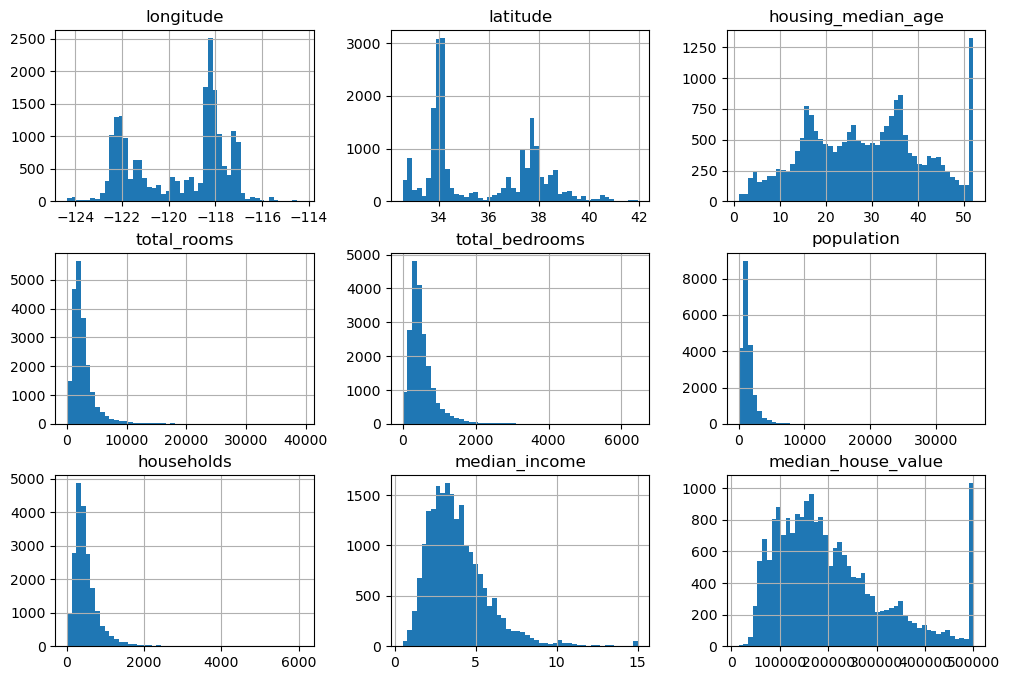

In [42]:
housing.hist(bins=50, figsize=(12, 8)) 
plt.show()

In [43]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

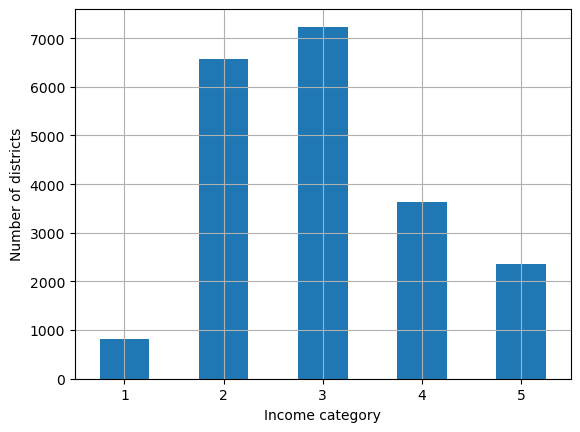

In [44]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [45]:
# Random splitting of data
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [46]:
# Stratifed splitting of data
strat_train_set, strat_test_set = train_test_split( 
housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [47]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set) 

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [48]:
housing["income_cat"].value_counts()/len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [49]:
test_set["income_cat"].value_counts()/len(test_set)

income_cat
3    0.345203
2    0.307413
4    0.184109
5    0.120882
1    0.042393
Name: count, dtype: float64

In [50]:
for set_ in (strat_train_set, strat_test_set): 
    set_.drop("income_cat", axis=1, inplace=True)

strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,500001.0,<1H OCEAN
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,88800.0,INLAND
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,148800.0,NEAR OCEAN
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,500001.0,<1H OCEAN


In [51]:
# copy of startified training data
housing = strat_train_set.copy()

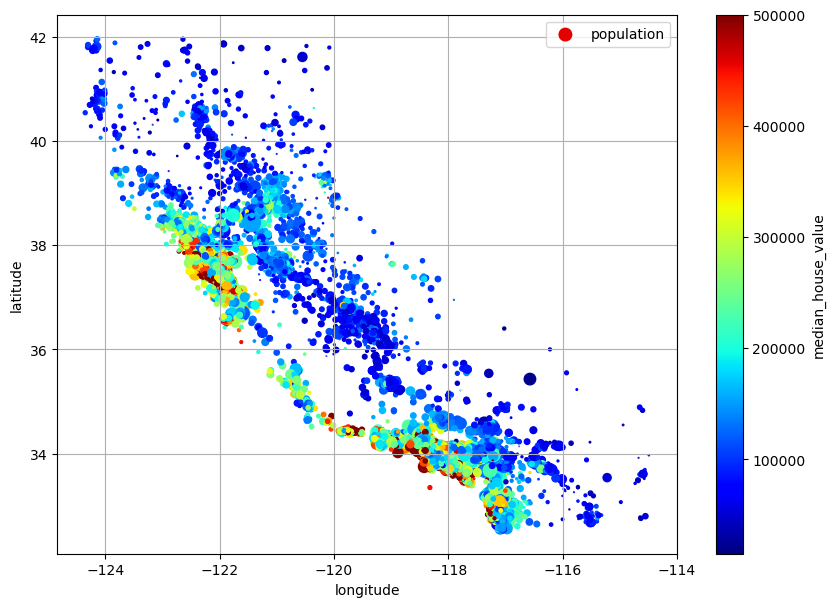

In [52]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True, 
             s=housing["population"]/100, label="population",
             c="median_house_value", cmap="jet", colorbar=True, 
             legend=True, sharex=False, figsize=(10, 7)
            )
plt.show()


In [53]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [54]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"] 
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"] 
housing["people_per_house"] = housing["population"] / housing["households"]

corr_matrix = housing.corr(numeric_only=True) 
corr_matrix["median_house_value"].sort_values(ascending=False) 

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [55]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [56]:
from sklearn.impute import SimpleImputer
import numpy as np

# Create imputer
imputer = SimpleImputer(strategy="median")

# Keep only numerical attributes
housing_num = housing.select_dtypes(include=[np.number])

# Calculate and store the median of each column
imputer.fit(housing_num)

# Check the learned medians
print(imputer.statistics_)
print(housing_num.median().values)

# Replace missing values with the learned medians
X = imputer.transform(housing_num)

[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]
[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]


In [57]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
housing_num = housing.select_dtypes(include=["number"])
housing_num_scaled = scaler.fit_transform(X)

In [59]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# Create a transformer that takes the logarithm
log_transformer = FunctionTransformer(
    np.log1p,
    inverse_func = np.expm1
)

x_log = log_transformer.transform(10)
print(x_log)

2.3978952727983707


In [60]:
# Numerical and categorical data are currently in separate variables, combine them.
import pandas as pd

# Convert scaled numerical data to DataFrame
housing_num_scaled_df = pd.DataFrame(
    housing_num_scaled,
    columns=housing_num.columns,
    index=housing.index
)

# Convert one-hot encoded data to DataFrame
housing_cat_1hot_df = pd.DataFrame(
    housing_cat_1hot.toarray(),
    columns=cat_encoder.get_feature_names_out(["ocean_proximity"]),
    index=housing.index
)

# Combine everything
X = pd.concat([housing_num_scaled_df, housing_cat_1hot_df], axis=1)

y = housing_labels

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,0.0,1.0,0.0,0.0,0.0
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,0.0,1.0,0.0,0.0,0.0
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,0.0,0.0,0.0,0.0,1.0


In [61]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_rmses = -cross_val_score(
    lin_reg,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("RMSE scores:", lin_rmses)
print("Mean RMSE:", lin_rmses.mean())
print("Standard deviation:", lin_rmses.std())

RMSE scores: [69823.93458835 67748.84358734 67256.04927007 69050.18214272
 67334.60772112 68688.9649581  67424.75877757 69952.42288885
 67537.81218643 68344.1931601 ]
Mean RMSE: 68316.17692806528
Standard deviation: 971.5373052470927


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

forest_reg = RandomForestRegressor(random_state=42)

forest_rmses = -cross_val_score(
    forest_reg,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("RMSE scores:", forest_rmses)
print("Mean RMSE:", forest_rmses.mean())
print("Standard deviation:", forest_rmses.std())

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_features": [4, 6, 8],
    "max_depth": [None, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X, y)

# hyperparameters that produced the lowest RMSE.
print(grid_search.best_params_)

# converts Scikit-Learn's negative score back into a normal positive RMSE.
best_rmse = -grid_search.best_score_
print("Best RMSE:", best_rmse)

# Random Forest model with the best hyperparameters.
best_forest = grid_search.best_estimator_